# 03 · Prediction and drift monitoring

Follow an approved model from one named-feature prediction to a structured monitoring event, then compare healthy and shifted traffic against the training baseline stored in the release artifact.

## Objectives

- Load a newly trained, approved model bundle.
- Inspect the full class-probability distribution.
- Build the same structured event emitted by the API and interface.
- Explain a drift alert in units of training standard deviation.

In [1]:
import logging
import os
from pathlib import Path
from tempfile import TemporaryDirectory

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")

import matplotlib.pyplot as plt
import pandas as pd

from mlops_demo.model import load_bundle
from mlops_demo.monitor import calculate_drift
from mlops_demo.telemetry import build_prediction_record
from mlops_demo.train import TrainingConfig, train_model
from mlops_demo.ui_support import predict_features, simulate_prediction_records

logging.getLogger("mlflow").setLevel(logging.WARNING)
plt.style.use("dark_background")
ACCENT = "#76B900"
HEALTHY = "#00BFA5"
ALERT = "#F59E0B"

## Prepare an approved model

The notebook trains into a temporary workspace so it runs independently and leaves the repository clean.

In [2]:
session = TemporaryDirectory(prefix="mlops-monitoring-notebook-")
workspace = Path(session.name)
config = TrainingConfig(
    artifacts_dir=workspace / "artifacts",
    tracking_dir=workspace / "mlruns",
    experiment_name="notebook-monitoring",
)
summary = train_model(config)
bundle = load_bundle(config.artifacts_dir / "model.joblib")
print(f"Approved model v{bundle.model_version} · held-out accuracy {summary['accuracy']:.1%}")

Approved model v0.2.0 · held-out accuracy 93.3%


## Make one prediction

Named features preserve the model contract at the interface boundary. The helper reorders them according to the bundle before inference.

In [3]:
features = {
    "sepal_length_cm": 5.1,
    "sepal_width_cm": 3.5,
    "petal_length_cm": 1.4,
    "petal_width_cm": 0.2,
}
predicted_class, probabilities = predict_features(bundle, features)
print(f"Predicted species: {predicted_class}")
pd.Series(probabilities, name="probability").to_frame().style.format("{:.1%}")

Predicted species: setosa


,probability
setosa,98.1%
versicolor,1.9%
virginica,0.0%


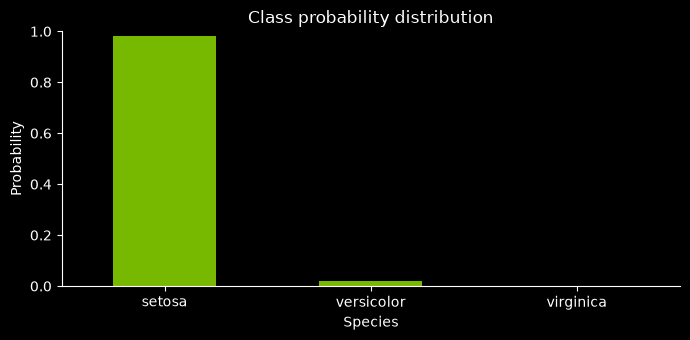

In [4]:
ax = pd.Series(probabilities).plot.bar(color=ACCENT, figsize=(7, 3.5), rot=0)
ax.set(title="Class probability distribution", xlabel="Species", ylabel="Probability", ylim=(0, 1))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Build the monitoring event

Predictions become useful operational signals only when their inputs, outputs, model version, and run lineage travel together.

In [5]:
event = build_prediction_record(
    bundle,
    features,
    predicted_class,
    probabilities,
)
pd.Series(
    {
        "timestamp": event["timestamp"],
        "predicted_class": event["predicted_class"],
        "model_version": event["model_version"],
        "run_id_prefix": str(event["run_id"])[:8],
        "feature_count": len(event["features"]),
    },
    name="prediction event",
).to_frame()

,prediction event
timestamp,2026-09-21T09:32:13.782676+00:00
predicted_class,setosa
model_version,0.2.0
run_id_prefix,8e0ea18f
feature_count,4


## Compare healthy and shifted traffic

The transparent monitor compares each live mean with the saved training mean. Dividing by the training standard deviation makes shifts comparable across differently scaled features.

In [6]:
healthy_records = simulate_prediction_records(bundle, sample_count=100, mean_shift_std=0.2)
shifted_records = simulate_prediction_records(bundle, sample_count=100, mean_shift_std=1.5)
healthy_report = calculate_drift(bundle, healthy_records, threshold=1.0)
shifted_report = calculate_drift(bundle, shifted_records, threshold=1.0)

print(f"Healthy window alert: {healthy_report['drift_detected']}")
print(f"Shifted window alert: {shifted_report['drift_detected']}")

Healthy window alert: False
Shifted window alert: True


In [7]:
comparison = pd.DataFrame(
    {
        "healthy_shift_std": {
            name: values["mean_shift_std"]
            for name, values in healthy_report["features"].items()
        },
        "shifted_shift_std": {
            name: values["mean_shift_std"]
            for name, values in shifted_report["features"].items()
        },
        "drifted": {
            name: values["drifted"]
            for name, values in shifted_report["features"].items()
        },
    }
)
comparison.round(3)

,healthy_shift_std,shifted_shift_std,drifted
sepal_length_cm,0.196,1.496,True
sepal_width_cm,0.188,1.488,True
petal_length_cm,0.211,1.511,True
petal_width_cm,0.202,1.502,True


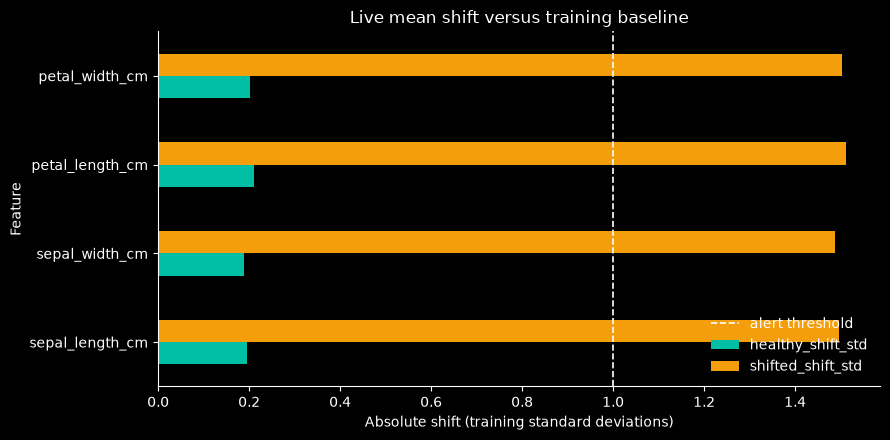

In [8]:
ax = comparison[["healthy_shift_std", "shifted_shift_std"]].plot.barh(
    color=[HEALTHY, ALERT],
    figsize=(9, 4.5),
)
ax.axvline(1.0, color="white", linestyle="--", linewidth=1.2, label="alert threshold")
ax.set(
    title="Live mean shift versus training baseline",
    xlabel="Absolute shift (training standard deviations)",
    ylabel="Feature",
)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Takeaways

- Inference uses the feature order saved with the approved model.
- Every prediction event remains attributable to a model version and training run.
- The simulated healthy window stays below the one-standard-deviation threshold.
- The shifted window crosses the threshold for every feature, producing an explainable alert rather than an opaque score.